In [10]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../../src/')
from build_model import xcit_small
from train_functions import train_epochs
from dataset_functions import hdf5_dataset, list_to_dict, viz_dataloader
from visualization_functions import show_images

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3,4,5,6,7"
print(os.environ["CUDA_VISIBLE_DEVICES"])
device = torch.device('cuda')

2,3,4,5,6,7


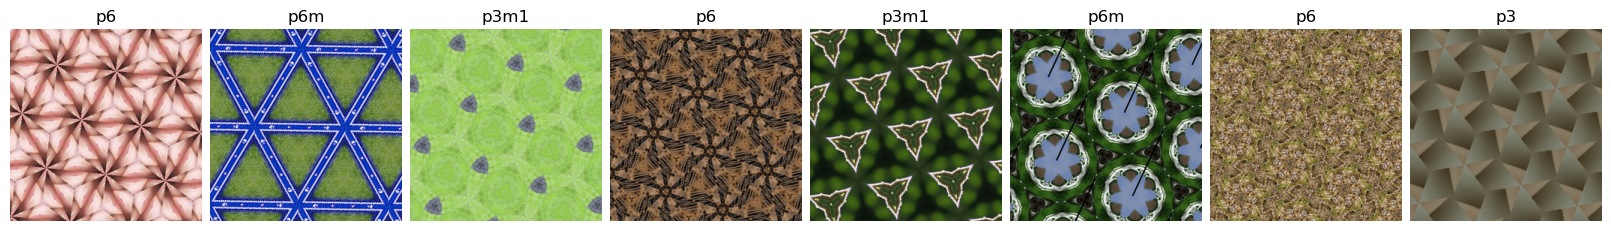

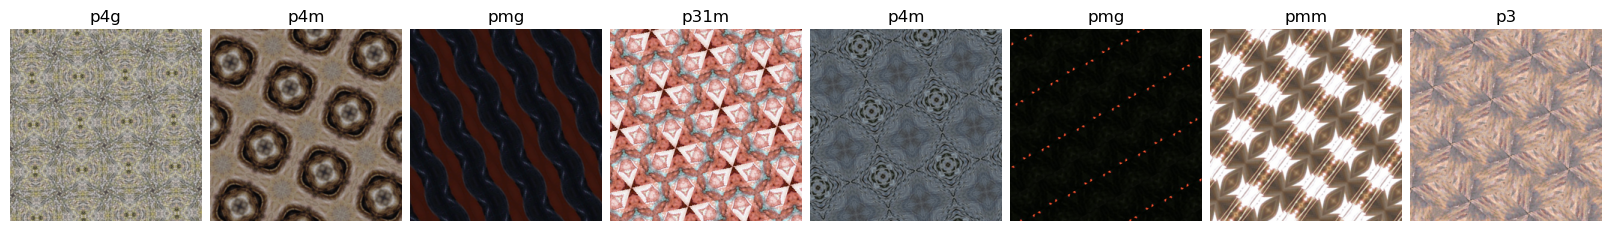

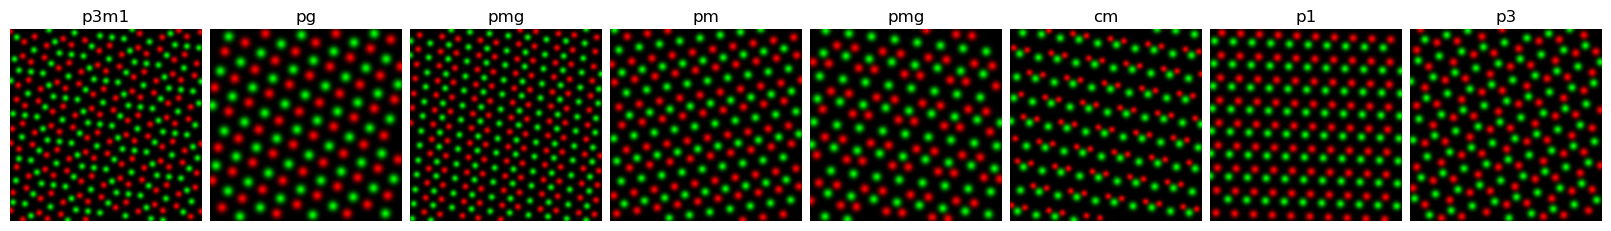

In [12]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('../../../../imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=400, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('../../../../imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=400, shuffle=True, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter)

# atom
test_ds = hdf5_dataset('../../../../atom_v4_rot_2m_unchunked_fixed.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=400, shuffle=True, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter)

# train

In [ ]:
import timm
timm.list_models('xcit*')

['xcit_large_24_p8_224',
 'xcit_large_24_p8_384',
 'xcit_large_24_p16_224',
 'xcit_large_24_p16_384',
 'xcit_medium_24_p8_224',
 'xcit_medium_24_p8_384',
 'xcit_medium_24_p16_224',
 'xcit_medium_24_p16_384',
 'xcit_nano_12_p8_224',
 'xcit_nano_12_p8_384',
 'xcit_nano_12_p16_224',
 'xcit_nano_12_p16_384',
 'xcit_small_12_p8_224',
 'xcit_small_12_p8_384',
 'xcit_small_12_p16_224',
 'xcit_small_12_p16_384',
 'xcit_small_24_p8_224',
 'xcit_small_24_p8_384',
 'xcit_small_24_p16_224',
 'xcit_small_24_p16_384',
 'xcit_tiny_12_p8_224',
 'xcit_tiny_12_p8_384',
 'xcit_tiny_12_p16_224',
 'xcit_tiny_12_p16_384',
 'xcit_tiny_24_p8_224',
 'xcit_tiny_24_p8_384',
 'xcit_tiny_24_p16_224',
 'xcit_tiny_24_p16_384']

In [13]:
model = xcit_small(3, 17)
model = nn.DataParallel(model)
print(model.to(device))
print(model(torch.randn(2, 3, 256, 256)).shape)

DataParallel(
  (module): Xcit(
    (patch_embed): ConvPatchEmbed(
      (proj): Sequential(
        (0): Sequential(
          (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): GELU(approximate='none')
        (2): Sequential(
          (0): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (3): GELU(approximate='none')
        (4): Sequential(
          (0): Conv2d(192, 384, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
    )
    (pos_embed): PositionalEncodingFourier(
      (token_projection): Conv2d(64, 384, kernel_size=(1, 1), stride=(1, 1))
    )
    (pos_drop): D

In [14]:
config = {
        'dataset': '10 million datasets',
        'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
        'optimizer': 'Adam',
        'scheduler': 'OneCycleLR',
        }

NAME = '01102024-benchmark-XCiT-v4_10m'

In [15]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


In [16]:
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_name=NAME, model_dir='../../../saved_models/', tracking=True)

Epoch: 1/20


  0%|          | 0/25001 [00:00<?, ?it/s]

100%|██████████| 25001/25001 [10:49:02<00:00,  1.56s/it] 


Training: Loss: 0.1682, Accuracy: 94.2243%, Time: 649.0464mins


100%|██████████| 5001/5001 [39:01<00:00,  2.14it/s]


...

100%|██████████| 5001/5001 [39:01<00:00,  2.14it/s]


Validation : Loss : 0.0151, Accuracy: 99.5396%, Time: 39.03mins


100%|██████████| 4682/4682 [36:41<00:00,  2.13it/s]


Validation : Loss : 4.3093, Accuracy: 46.5210%, Time: 36.69mins
Epoch: 4/20


 71%|███████   | 17704/25001 [7:39:43<3:07:58,  1.55s/it]

# analyze

In [ ]:
device = torch.device('cuda')
model = torch.load('../../../saved_models/', map_location=device)

NAME = 'benchmark-XCiT-v4_10m'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']                  

In [ ]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

100%|██████████| 43479/43479 [2:17:30<00:00,  5.27it/s]  


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 0.9996354029167767


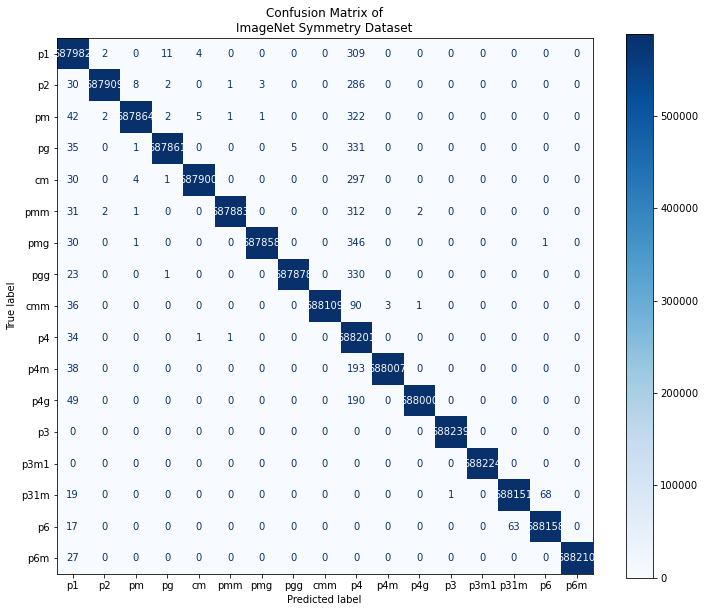

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 8696/8696 [27:55<00:00,  5.19it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.9991540067679459


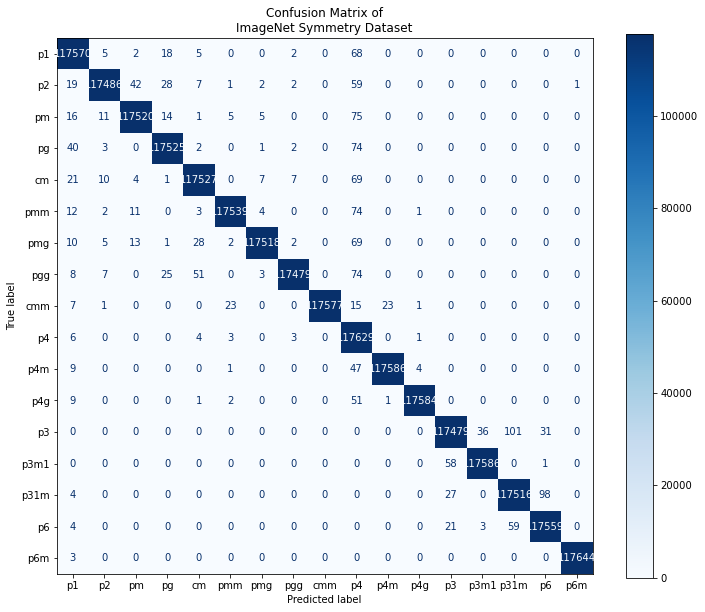

In [ ]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

100%|██████████| 1985/1985 [29:26<00:00,  1.12it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5805782531969523


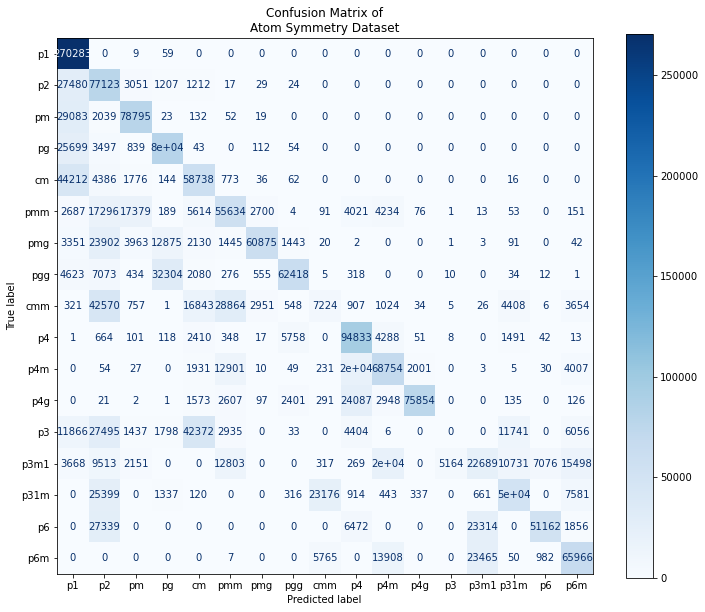

In [ ]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')